Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/Users/asim/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

WARNING ⚠️ Dataset 'african-wildlife.yaml' images not found, missing path '/Users/asim/Desktop/CNN/datasets/african-wildlife/images/val'
Unzipping /Users/asim/Desktop/CNN/datasets/african-wildlife.zip to /Users/asim/Desktop/CNN/datasets/african-wildlife...: 100% ━━━━━━━━━━━━ 3018/3018 6.9Kfiles/s 0.4s0.0s
Dataset download success ✅ (25.8s), saved to /Users/asim/Desktop/CNN/datasets

Classes: {0: 'buffalo', 1: 'elephant', 2: 'rhino', 3: 'zebra'}
Train images: /Users/asim/Desktop/CNN/datasets/african-wildlife/images/train
Val images:   /Users/asim/Desktop/CNN/datasets/african-wildlife/images/val

Image: 3 (64).jpg
Raw label file:
2 0.575099 0.568241 0.8339

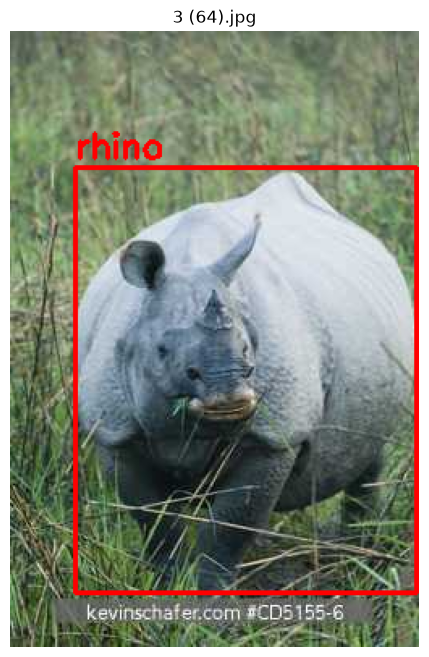

In [3]:
# 01_setup_and_data.py
# Goal: get the data, then actually LOOK at what a YOLO annotation is.

from pathlib import Path
import random
import cv2                      # comes bundled with ultralytics
import matplotlib.pyplot as plt
from ultralytics.data.utils import check_det_dataset

# ── 1. Download / locate the dataset ──────────────────────────────
# On first run this downloads African-wildlife and returns resolved paths.
data = check_det_dataset("african-wildlife.yaml")

print("Classes:", data["names"])        # {0: 'buffalo', 1: 'elephant', ...}
print("Train images:", data["train"])
print("Val images:  ", data["val"])

# ── 2. Grab ONE training image + its label file ───────────────────
train_img_dir = Path(data["train"])
train_lbl_dir = Path(str(train_img_dir).replace("images", "labels"))

img_path = random.choice(list(train_img_dir.glob("*.jpg")))
lbl_path = train_lbl_dir / (img_path.stem + ".txt")   # same name, .txt

lines = lbl_path.read_text().strip().splitlines()
print(f"\nImage: {img_path.name}")
print("Raw label file:")
print("\n".join(lines))

# ── 3. Decode the format ──────────────────────────────────────────
# Each line = ONE object = <class_id> <x_center> <y_center> <w> <h>
# ALL five-value coords are NORMALIZED to [0,1] — fractions of the
# image, NOT pixels.
img = cv2.imread(str(img_path))
h, w = img.shape[:2]
print(f"\nImage is {w}x{h} px. Decoding each line into pixels:")
for line in lines:
    cid, xc, yc, bw, bh = map(float, line.split())
    print(f"  {data['names'][int(cid)]:9s} "
          f"center=({xc*w:.0f},{yc*h:.0f}) box={bw*w:.0f}x{bh*h:.0f} px")

# ── 4. Draw the boxes so you SEE numbers become a box ─────────────
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
for line in lines:
    cid, xc, yc, bw, bh = map(float, line.split())
    x1, y1 = int((xc - bw/2) * w), int((yc - bh/2) * h)   # center → corners
    x2, y2 = int((xc + bw/2) * w), int((yc + bh/2) * h)
    cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2.putText(img_rgb, data["names"][int(cid)], (x1, y1 - 6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

plt.figure(figsize=(8, 8)); plt.axis("off")
plt.title(img_path.name); plt.imshow(img_rgb); plt.show()